In [1]:
##### Figures 3/4: exposed capital & labor globally (fig 3) and by country (fig 4)

import pandas as pd
import geopandas as gpd
import numpy as np
import rasterio
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import rasterio.features
from matplotlib import gridspec
import xarray as xr

from reproject_raster import reproject_raster, array_to_raster

In [2]:
##### Load data

cd = Path.cwd().parent

# capital rasters
capital_path = f"{cd}/Results/Raster_models/rescaled_capital_USD.tif"
capital_country_avg_path = f"{cd}/Results/Raster_models/country_avg_model/rescaled_capital_USD.tif"

# labor rasters
labor_path = f"{cd}/Results/Raster_models/rescaled_jobs.tif"
labor_country_avg_path = f"{cd}/Results/Raster_models/country_avg_model/rescaled_jobs.tif"

# production raster
production_path = f'{cd}/Data/total_production_tonnes_2020.tif'

# conservation scenario raster
# 0 = no in top 30%, 1 = in top 30%, not PA, 2 = in top 30%, already PA
biodiversity_with_PA = f"{cd}/Data/conservation_scenario.tif"

# country boundaries (need to download GADM 401 and add to data folder https://gadm.org/data.html)
country_shp = gpd.read_file(f"{cd}/Data/gadm_410-levels.gpkg", layer='ADM_0')
country_codes = pd.read_csv(f"{cd}/Data/country_names.csv", encoding="cp1252")

# Set file path to figure repo
FIG_DIR = Path(f"{cd}/Figures/")
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
##### Data prep

# Resample to match conservation scneario (equal area projection)
production_arr = reproject_raster(production_path, resampling="sum")
production = array_to_raster(production_arr)

capital_arr = reproject_raster(capital_path, resampling="sum")
capital = array_to_raster(capital_arr)

capital_country_avg_arr = reproject_raster(capital_country_avg_path, resampling="sum")
capital_country_avg = array_to_raster(capital_country_avg_arr)

labor_arr = reproject_raster(labor_path, resampling="sum")
labor = array_to_raster(labor_arr)

labor_country_avg_arr = reproject_raster(labor_country_avg_path, resampling="sum")
labor_country_avg = array_to_raster(labor_country_avg_arr)

In [4]:
##### Shared helper / styling

def read_array(src, band=1):
    if isinstance(src, xr.DataArray):
        if "band" in src.dims:
            src = src.isel(band=band - 1)
        return src.squeeze().values.astype(float) 

    with rasterio.open(src) as r:
        arr = r.read(band).astype(float)
        nodata = r.nodata
        if nodata is not None:
            arr[arr == nodata] = np.nan
    return arr

COLORS = {
    "Capital": "#2F7C87",
    "Labor": "#C96A3B",
    "Production": "#6B7280",
    "Area": "#8E5B9F",
}

STATUS_COLORS = {
    "Additional priority": "#D9D9D9",
    "Already in PA": "#595959",
}

TITLE_FS = 8   # subplot titles
LABEL_FS = 7   # axis and legend labels
TICK_FS = 6    # tick labels

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"],
    "font.size": TICK_FS,
    "axes.titlesize": TITLE_FS,
    "axes.labelsize": LABEL_FS,
    "xtick.labelsize": TICK_FS,
    "ytick.labelsize": TICK_FS,
    "legend.fontsize": LABEL_FS,
})

priority_arr = read_array(biodiversity_with_PA)

# Observed/model values
value_rasters = {
    "Capital": capital,
    "Labor": labor,
    "Production": production,
}

In [5]:
##### Global summary table 

summary_rows = []

for variable, path in value_rasters.items():
    value_arr = read_array(path)
    global_total = np.nansum(value_arr)

    additional = np.nansum(value_arr[priority_arr == 1])
    already = np.nansum(value_arr[priority_arr == 2])
    total = additional + already

    summary_rows.append({
        "Variable": variable,
        "Additional_priority": additional,
        "Already_in_PA": already,
        "Total_priority": total,
        "Pct_additional": 100 * additional / global_total,
        "Pct_already": 100 * already / global_total,
        "Pct_total": 100 * total / global_total,
        "Global_total": global_total,
    })

summary_df = pd.DataFrame(summary_rows)

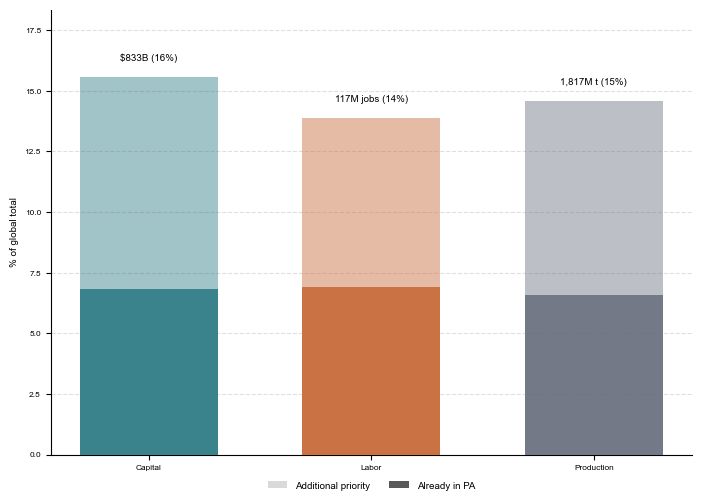

In [6]:
##### FIGURE 3: % of global capital, labor, production in priority regions

variables = ["Capital", "Labor", "Production"]
x = np.arange(len(variables))
width = 0.62

fig, ax = plt.subplots(figsize=(7, 5))

for i, variable in enumerate(variables):
    row = summary_df.loc[
        summary_df["Variable"] == variable
    ].iloc[0]

    # Darker shade = already PA; lighter shade = additional priority.
    # alpha distinguishs the two portions
    ax.bar(
        i,
        row["Pct_already"],
        width,
        color=COLORS[variable],
        alpha=0.95,
        zorder=3,
    )

    ax.bar(
        i,
        row["Pct_additional"],
        width,
        bottom=row["Pct_already"],
        color=COLORS[variable],
        alpha=0.45,
        zorder=3,
    )

    # Absolute total + percentage label
    value = row["Total_priority"]

    if variable == "Capital":
        value_label = (
            f"${value / 1e9:,.0f}B"
            if value >= 1e9
            else f"${value / 1e6:,.0f}M"
        )
    elif variable == "Labor":
        value_label = (
            f"{value / 1e6:,.0f}M jobs"
            if value >= 1e6
            else f"{value / 1e3:,.0f}K jobs"
        )
    else:
        value_label = (
            f"{value / 1e6:,.0f}M t"
            if value >= 1e6
            else f"{value / 1e3:,.0f}K t"
        )

    ax.text(
        i,
        row["Pct_total"] + 0.6,
        f"{value_label} ({row['Pct_total']:.0f}%)",
        ha="center",
        va="bottom",
        fontsize=LABEL_FS,
    )

ax.set_xticks(x)
ax.set_xticklabels(variables)
ax.set_ylabel("% of global total")

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
ax.set_axisbelow(True)
ax.set_ylim(0, max(summary_df["Pct_total"]) * 1.18)

legend_elements = [
    Patch(facecolor=STATUS_COLORS["Additional priority"], label="Additional priority"),
    Patch(facecolor=STATUS_COLORS["Already in PA"], label="Already in PA"),
]

ax.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    frameon=False,
)

plt.tight_layout()
plt.savefig(
    FIG_DIR / "Figure_3_global_exposure.tiff",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [7]:
##### Prepare country-level data on capital, labor, and production in priority areas

# Merge country codes
country_shp = country_shp.merge(
    country_codes,
    left_on="GID_0",
    right_on="SHP_code",
    how="left",
)

# Use the capital raster as the reference grid
ref_transform = capital.rio.transform()
ref_shape = (capital.rio.height, capital.rio.width)
ref_crs = capital.rio.crs 

country_shp_proj = (
    country_shp.to_crs(ref_crs)
    if country_shp.crs != ref_crs
    else country_shp.copy()
).reset_index(drop=True)

# Rasterize countries
shapes = (
    (geom, i)
    for i, geom in enumerate(country_shp_proj.geometry)
    if geom is not None
)

country_id_arr = rasterio.features.rasterize(
    shapes=shapes,
    out_shape=ref_shape,
    transform=ref_transform,
    fill=-1,
    dtype="int32",
)

n_countries = len(country_shp_proj)
row_to_iso3 = country_shp_proj["ISO3"].to_dict()


def zonal_sum_by_country(
    value_arr,
    priority_arr,
    class_value,
    country_id_arr,
    n_countries,
):
    valid = (
        (country_id_arr >= 0)
        & (priority_arr == class_value)
        & ~np.isnan(value_arr)
    )

    return np.bincount(
        country_id_arr[valid],
        weights=value_arr[valid],
        minlength=n_countries,
    )


# Country-average rasters
country_avg_rasters = {
    "Capital": capital_country_avg,
    "Labor": labor_country_avg,
}


# National totals 
national_totals = {}

for variable, path in value_rasters.items():
    arr = read_array(path)
    valid = (country_id_arr >= 0) & ~np.isnan(arr)

    totals = np.bincount(
        country_id_arr[valid],
        weights=arr[valid],
        minlength=n_countries,
    )

    national_totals[variable] = {
        row_to_iso3[i]: totals[i]
        for i in range(n_countries)
    }


# Country-level priority totals
country_rows = []

for variable, path in value_rasters.items():
    arr = read_array(path)

    for class_value, class_name in [
        (1, "Additional priority"),
        (2, "Already in PA"),
    ]:
        sums = zonal_sum_by_country(
            arr,
            priority_arr,
            class_value,
            country_id_arr,
            n_countries,
        )

        for i in range(n_countries):
            iso3 = row_to_iso3[i]
            national_total = national_totals[variable].get(
                iso3,
                np.nan,
            )

            country_rows.append({
                "ISO3": iso3,
                "Variable": variable,
                "Class": class_name,
                "Sum": sums[i],
                "National_Total": national_total,
            })

country_df = pd.DataFrame(country_rows)


# Priority-area-only global totals
global_priority_totals = {
    variable: np.nansum(
        read_array(path)[(priority_arr == 1) | (priority_arr == 2)]
    )
    for variable, path in value_rasters.items()
}

country_df["Pct_of_national"] = np.where(
    country_df["National_Total"] > 0,
    100 * country_df["Sum"] / country_df["National_Total"],
    np.nan,
)

country_df["Global_Total"] = country_df["Variable"].map(global_priority_totals)

country_df["Pct_of_global"] = (
    100 * country_df["Sum"] / country_df["Global_Total"]
)


# Total priority value by country
country_totals = (
    country_df
    .groupby(["ISO3", "Variable"], as_index=False)
    .agg(
        Priority_Total=("Sum", "sum"),
        National_Total=("National_Total", "first"),
        Pct_of_national=("Pct_of_national", "sum"),
        Pct_of_global=("Pct_of_global", "sum"),
    )
)

In [8]:
##### Export country-level summary CSV 

# Pivot to wide
export_df = country_totals.pivot(
    index="ISO3",
    columns="Variable",
    values=["Pct_of_global", "Pct_of_national"],
)

export_df.columns = [
    f"{metric}_{variable}"
    for metric, variable in export_df.columns
]

export_df = export_df.reset_index()

# Add country names
name_col = next(
    (
        c
        for c in [
            "COUNTRY",
            "NAME_0",
            "Country",
            "country_name",
        ]
        if c in country_shp_proj.columns
    ),
    None,
)

if name_col:
    name_lookup = (
        country_shp_proj[["ISO3", name_col]]
        .drop_duplicates("ISO3")
        .set_index("ISO3")[name_col]
    )
    export_df.insert(
        1,
        "Country",
        export_df["ISO3"].map(name_lookup),
    )

# Rename columns 
export_df = export_df.rename(columns={
    "Pct_of_global_Capital": "Pct_global_capital_in_country",
    "Pct_of_global_Labor": "Pct_global_labor_in_country",
    "Pct_of_global_Production": "Pct_global_production_in_country",
    "Pct_of_national_Capital": "Pct_national_capital_exposed",
    "Pct_of_national_Labor": "Pct_national_labor_exposed",
    "Pct_of_national_Production": "Pct_national_production_exposed",
})

# Order columns 
ordered_cols = ["ISO3", "Country"] if name_col else ["ISO3"]
ordered_cols += [
    "Pct_global_capital_in_country",
    "Pct_global_labor_in_country",
    "Pct_global_production_in_country",
    "Pct_national_capital_exposed",
    "Pct_national_labor_exposed",
    "Pct_national_production_exposed",
]
ordered_cols = [c for c in ordered_cols if c in export_df.columns]
export_df = export_df[ordered_cols]

export_df = export_df[export_df["ISO3"] != "OTHER"].sort_values(
    "Pct_global_capital_in_country", ascending=False
)

export_df.to_csv(FIG_DIR / "country_exposure_summary.csv", index=False)

/var/folders/48/ky2jtbmj31bfj15cr5gq480w0000gn/T/ipykernel_56173/751765060.py:262: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


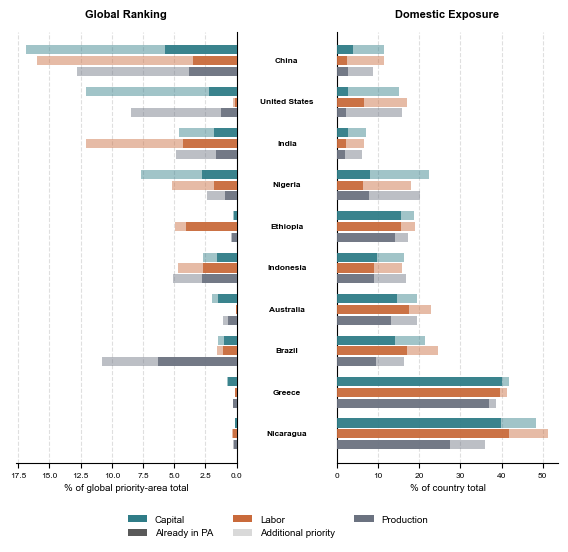

In [9]:
##### FIGURE 4: country exposure butterfly chart

# Manually specify which countries to include 
selected_countries = [
    "CHN",
    "USA",
    "IND",
    "NGA",
    "ETH",
    "IDN",
    "AUS",
    "BRA",
    "GRC",
    "NIC",
]


def plot_country_butterfly(
    country_df,
    country_totals,
    country_shp_proj,
    country_list,
):

    name_col = next(
        (
            c
            for c in [
                "COUNTRY",
                "NAME_0",
                "Country",
                "country_name",
            ]
            if c in country_shp_proj.columns
        ),
        None,
    )

    if name_col:
        name_lookup = (
            country_shp_proj[
                ["ISO3", name_col]
            ]
            .drop_duplicates("ISO3")
            .set_index("ISO3")[name_col]
        )
    else:
        name_lookup = pd.Series(dtype=object)

    def get_values(iso3, variable, pct_col):
        sub = country_df[
            (country_df["ISO3"] == iso3)
            & (country_df["Variable"] == variable)
        ]

        already = sub.loc[
            sub["Class"] == "Already in PA",
            pct_col,
        ].sum()

        additional = sub.loc[
            sub["Class"] == "Additional priority",
            pct_col,
        ].sum()

        return already, additional

    n = len(country_list)
    bar_h = 0.22
    offset = bar_h + 0.04

    fig = plt.figure(
        figsize=(7, 0.4 * n + 1.6)
    )

    gs = gridspec.GridSpec(
        1,
        3,
        width_ratios=[4, 1.5, 4],
        wspace=0.05,
    )

    ax_left = fig.add_subplot(gs[0])
    ax_mid = fig.add_subplot(gs[1], sharey=ax_left)
    ax_right = fig.add_subplot(gs[2], sharey=ax_left)

    y_positions = np.arange(n)[::-1]

    for y, iso3 in zip(
        y_positions,
        country_list,
    ):

        for variable, y_off in [
            ("Capital", offset),
            ("Labor", 0),
            ("Production", -offset),
        ]:

            already_g, additional_g = get_values(
                iso3,
                variable,
                "Pct_of_global",
            )

            already_n, additional_n = get_values(
                iso3,
                variable,
                "Pct_of_national",
            )

            # Global distribution
            ax_left.barh(
                y + y_off,
                already_g,
                bar_h,
                color=COLORS[variable],
                alpha=0.95,
                zorder=3,
            )

            ax_left.barh(
                y + y_off,
                additional_g,
                bar_h,
                left=already_g,
                color=COLORS[variable],
                alpha=0.45,
                zorder=3,
            )

            # National exposure
            ax_right.barh(
                y + y_off,
                already_n,
                bar_h,
                color=COLORS[variable],
                alpha=0.95,
                zorder=3,
            )

            ax_right.barh(
                y + y_off,
                additional_n,
                bar_h,
                left=already_n,
                color=COLORS[variable],
                alpha=0.45,
                zorder=3,
            )

    # Axes
    ax_left.set_xlabel(
        "% of global priority-area total",
        fontsize=LABEL_FS,
    )

    ax_left.invert_xaxis()

    ax_left.spines[
        ["top", "left"]
    ].set_visible(False)

    ax_left.grid(
        axis="x",
        linestyle="--",
        alpha=0.4,
        zorder=0,
    )

    ax_left.set_axisbelow(True)
    ax_left.set_title(
        "Global Ranking",
        fontsize=TITLE_FS,
        fontweight="bold",
        pad=10,
    )

    ax_left.yaxis.set_visible(False)

    ax_right.set_xlabel(
        "% of country total",
        fontsize=LABEL_FS,
    )

    ax_right.spines[
        ["top", "right"]
    ].set_visible(False)

    ax_right.grid(
        axis="x",
        linestyle="--",
        alpha=0.4,
        zorder=0,
    )

    ax_right.set_axisbelow(True)

    ax_right.set_title(
        "Domestic Exposure",
        fontsize=TITLE_FS,
        fontweight="bold",
        pad=10,
    )

    ax_right.yaxis.set_visible(False)

    ax_mid.axis("off")

    for y, iso3 in zip(
        y_positions,
        country_list,
    ):
        ax_mid.text(
            0.5,
            y,
            name_lookup.get(iso3, iso3),
            ha="center",
            va="center",
            fontsize=TICK_FS,
            fontweight="bold",
        )

    ax_mid.set_xlim(0, 1)
    ax_left.set_ylim(-0.7, n - 0.3)

    # Legend
    # col1: Capital/Already in PA, col2: Labor/Additional priority, col3: Production
    legend_elements = [
        Patch(
            facecolor=COLORS["Capital"],
            label="Capital",
        ),
        Patch(
            facecolor=STATUS_COLORS["Already in PA"],
            label="Already in PA",
        ),
        Patch(
            facecolor=COLORS["Labor"],
            label="Labor",
        ),
        Patch(
            facecolor=STATUS_COLORS["Additional priority"],
            label="Additional priority",
        ),
        Patch(
            facecolor=COLORS["Production"],
            label="Production",
        ),
    ]

    fig.legend(
        handles=legend_elements,
        loc="lower center",
        ncol=3,
        bbox_to_anchor=(0.5, -0.04),
        frameon=False,
        fontsize=LABEL_FS,
    )


    plt.tight_layout(
        rect=[0, 0, 1, 0.93]
    )

    plt.savefig(
        FIG_DIR / "Figure_4_country_exposure.tiff",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

plot_country_butterfly(
    country_df,
    country_totals,
    country_shp_proj,
    selected_countries,
)